In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
import pandas as pd

from config import BINANCE_PATH, RESULTS_PATH

as_results = pd.read_parquet(BINANCE_PATH / 'as_results.parquet')
symmetric_results = pd.read_parquet(BINANCE_PATH / 'symmetric_results.parquet')

In [4]:
import backtest.run

table = pd.DataFrame([backtest.run.summarize(as_results, 'as'), backtest.run.summarize(symmetric_results, 'symmetric')])
table.to_csv(RESULTS_PATH / 'train_comparison.csv', index = False)
print(table)

    strategy  terminal_wealth   spread_pnl     inv_pnl  bid_fills  ask_fills  \
0         as     -2234.835127  3779.255373  -6014.0905      25516      25518   
1  symmetric    -14198.091031  4304.386969 -18502.4780      23947      24216   

   mean_spread     q_std  mean_abs_q  max_abs_q  
0    17.874248  0.058619    0.045721       0.31  
1    17.874248  1.229412    2.888816       5.31  


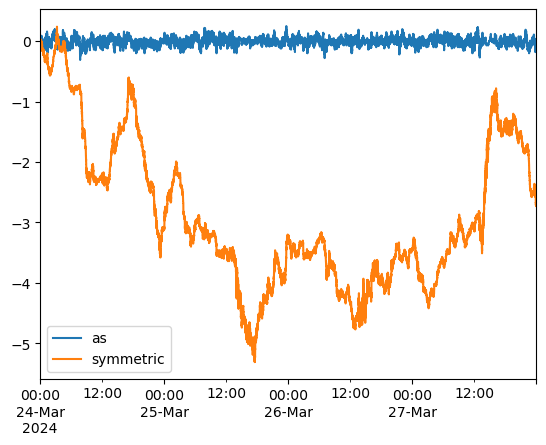

In [5]:
import matplotlib.pyplot as plt

ax = as_results['q'].plot(label = 'as')
symmetric_results['q'].plot(ax = ax, label = 'symmetric')
plt.legend()
plt.show()

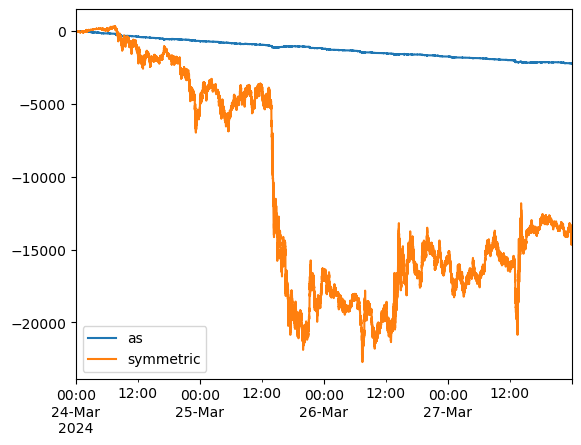

In [6]:
ax = as_results['wealth'].plot(label = 'as')
symmetric_results['wealth'].plot(ax = ax, label = 'symmetric')
plt.legend()
plt.show()